In [1]:
import pandas as pd

In [2]:
teams = pd.read_csv("teams.csv")
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [3]:
teams = teams[["team", "country","year", "athletes", "age", "prev_medals", "medals"]]
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [4]:
teams.corr(numeric_only=True)["medals"].sort_values(ascending=False)

medals         1.000000
prev_medals    0.920048
athletes       0.840817
age            0.025096
year          -0.021603
Name: medals, dtype: float64

In [5]:
import seaborn as sns

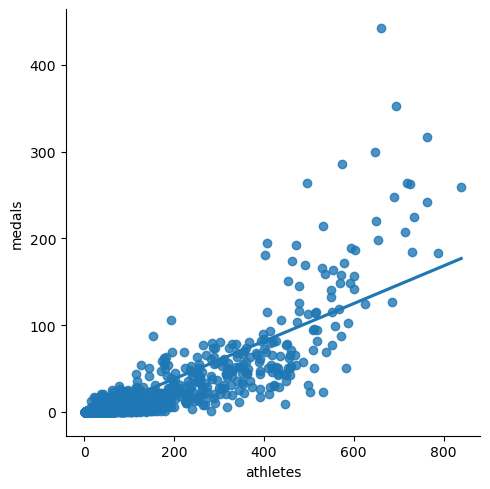

In [6]:
sns.lmplot(x="athletes", y="medals", data=teams, fit_reg=True, ci=None)

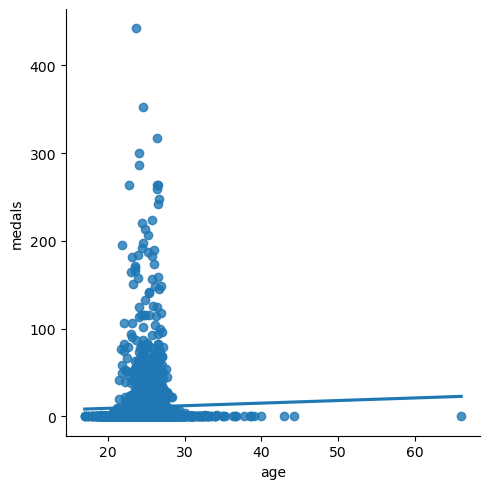

In [7]:
sns.lmplot(x="age", y="medals", data=teams, fit_reg=True, ci=None)

<Axes: ylabel='Frequency'>

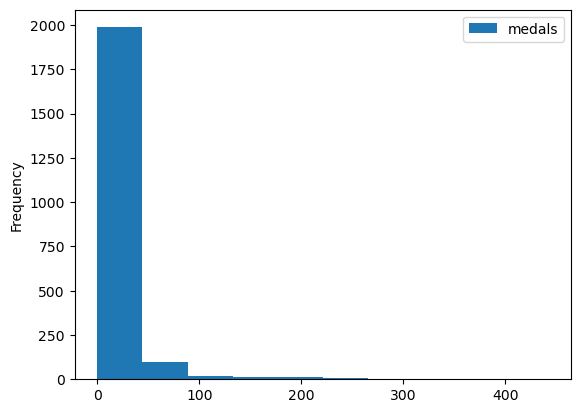

In [8]:
teams.plot.hist(y="medals")

In [9]:
teams[teams.isnull().any(axis=1)]

,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,NaN,0
2103,YAR,North Yemen,1984,3,27.7,NaN,0
2105,YEM,Yemen,1992,8,19.6,NaN,0
2112,YMD,South Yemen,1988,5,23.6,NaN,0


In [10]:
teams = teams.dropna()

In [11]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [12]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [13]:
target = "medals"
baseline_value = train[target].median()
baseline_value

0.0

In [14]:
train.shape

(1609, 7)

In [15]:
test.shape

(405, 7)

In [16]:
# train model
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [17]:
predictors=["athletes", "prev_medals"]
target = "medals"

In [18]:
reg.fit(train[predictors], train["medals"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
predictions = reg.predict(test[predictors])

In [20]:
test["baseline_pred"] = baseline_value

In [21]:
test["predictions"] = predictions
test

,team,country,year,athletes,age,prev_medals,medals,baseline_pred,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,0.0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,0.0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,0.0,2.155629
...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0,-1.926958
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0,-1.640143
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0,-1.640143
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,0.0,1.505767


In [22]:
test.loc[test["predictions"] < 0, "predictions"] = 0

In [23]:
test["predictions"] = test["predictions"].round()

In [24]:
test

,team,country,year,athletes,age,prev_medals,medals,baseline_pred,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,0.0,2.0
...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,0.0,2.0


In [25]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["medals"], test["predictions"])
error

3.2987654320987656

In [26]:
baseline_mae = mean_absolute_error(test["medals"], test["baseline_pred"])
baseline_mae

9.785185185185185

In [27]:
print("Baseline MAE: ", baseline_mae)
print("Model MAE: ", error)
print("Improvement: ", baseline_mae - error)

Baseline MAE:  9.785185185185185
Model MAE:  3.2987654320987656
Improvement:  6.48641975308642


In [28]:
test[["team","medals","predictions","baseline_pred"]].head(10)

,team,medals,predictions,baseline_pred
6,AFG,1,0.0,0.0
7,AFG,0,0.0,0.0
24,ALB,0,0.0,0.0
25,ALB,0,0.0,0.0
37,ALG,1,2.0,0.0
38,ALG,2,4.0,0.0
48,AND,0,0.0,0.0
49,AND,0,0.0,0.0
57,ANG,0,0.0,0.0
58,ANG,0,0.0,0.0


In [29]:
import matplotlib.pyplot as plt

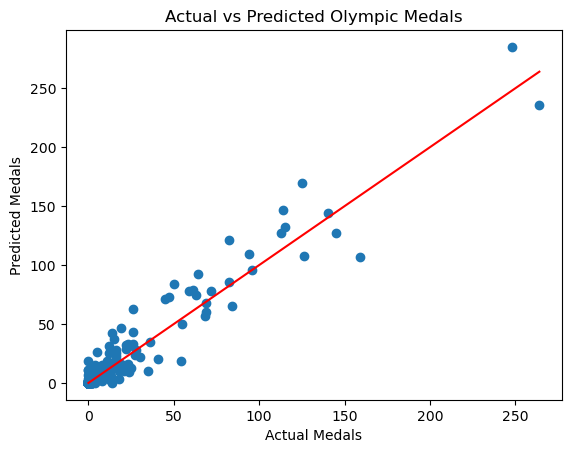

In [30]:
plt.scatter(test["medals"], test["predictions"])
plt.plot([0, max(test["medals"])],
         [0, max(test["medals"])],
         color="red")
plt.xlabel("Actual Medals")
plt.ylabel("Predicted Medals")
plt.title("Actual vs Predicted Olympic Medals")
plt.show()

In [31]:
teams.describe()["medals"]
#if MAE is significantly lower than STD, it usually indicates that the model is learning meaningful patterns.

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [32]:
test[test["team"] == "USA"]

,team,country,year,athletes,age,prev_medals,medals,baseline_pred,predictions
2053,USA,United States,2012,689,26.7,317.0,248,0.0,285.0
2054,USA,United States,2016,719,26.4,248.0,264,0.0,236.0


In [33]:
test[test["team"] == "CHN"]

,team,country,year,athletes,age,prev_medals,medals,baseline_pred,predictions
404,CHN,China,2012,479,24.0,184.0,125,0.0,170.0
405,CHN,China,2016,499,24.0,125.0,113,0.0,127.0


In [34]:
# The difference between how many metals we predictied and how many metals were actually earned 
errors = (test["medals"] - test["predictions"]).abs()
errors

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [35]:
# now we have how many medals off we were on average for each country 
error_by_team = errors.groupby(test["team"]).mean()
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64

In [36]:
# how many medals each country earned each country on average
medals_by_team = test["medals"].groupby(test["team"]).mean()
medals_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    0.0
Name: medals, Length: 204, dtype: float64

In [37]:
# find ratio between our errors
error_ratio = error_by_team / medals_by_team
error_ratio

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    inf
Length: 204, dtype: float64

In [38]:
# take the value thats not missing
error_ratio[~pd.isnull(error_ratio)]

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
ZIM         inf
Length: 102, dtype: float64

In [39]:
# clean the infinite value e.g 1/0
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]
error_ratio

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
UKR    0.951220
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

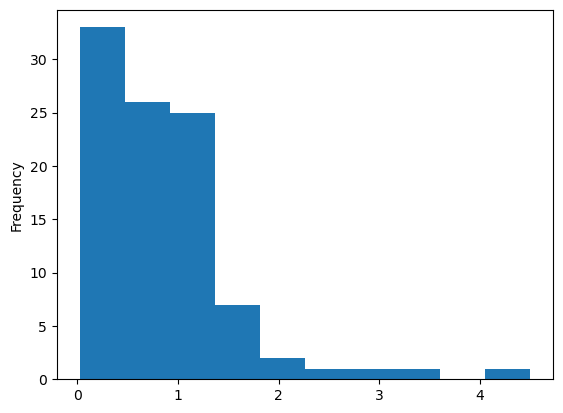

In [40]:
error_ratio.plot.hist()

In [41]:
error_ratio.sort_values()

team
FRA    0.022472
CAN    0.048387
NZL    0.063492
RUS    0.082353
ITA    0.121429
         ...   
MAR    2.000000
EGY    2.400000
HKG    3.000000
POR    3.333333
AUT    4.500000
Length: 97, dtype: float64